# Fraud Detection in Internship Applications

## Project Overview

Online internship portals receive thousands of applications from candidates with diverse educational backgrounds. As the number of applications increases, organizations face challenges in identifying suspicious or fraudulent submissions that may affect the fairness, transparency, and efficiency of the recruitment process.

This project analyzes an internship application dataset containing **100,000 application records** using **Data Analytics** and **Machine Learning** techniques to identify suspicious application patterns. The analysis focuses on common fraud indicators such as duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid application submissions, incomplete applicant profiles, missing resumes, and inconsistent applicant data.

Exploratory Data Analysis (EDA) is performed to understand applicant behavior and identify fraud patterns within the dataset. Furthermore, **Isolation Forest** is applied for anomaly detection, while **K-Means Clustering** is used to group applications with similar characteristics. Finally, applications are categorized into different fraud risk levels to support effective recruitment decisions and facilitate further investigation of suspicious applications.

## Project Objectives

The main objectives of this project are:

- Identify anomalous internship applications to detect suspicious and potentially fraudulent submissions.
- Analyze common fraud indicators, including duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid application submissions, missing resumes, low profile completion, and inconsistent applicant data.
- Explore applicant behavior and fraud patterns using Exploratory Data Analysis (EDA).
- Apply the Isolation Forest algorithm to detect anomalous internship applications.
- Apply K-Means Clustering to group applications with similar characteristics.
- Categorize applications into different fraud risk levels to support effective decision-making and further investigation.

## Machine Learning Algorithms

The following unsupervised machine learning algorithms are used in this project to analyze internship applications, identify suspicious patterns, and support fraud detection.

### 1. Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm that identifies unusual internship applications by isolating observations that significantly differ from normal application behavior.

**Purpose:**

- Detect anomalous internship applications.
- Identify suspicious application behavior based on fraud-related features.
- Support fraud detection by highlighting potential anomalies for further investigation.


### 2. K-Means Clustering

K-Means Clustering is an unsupervised machine learning algorithm that groups internship applications into clusters based on similarities in applicant characteristics and application behavior.

**Purpose:**

- Discover hidden patterns within the internship application dataset.
- Group similar applications into meaningful clusters.
- Analyze behavioral differences among applicant groups.
- Support exploratory analysis of fraud-related application patterns.

## Dataset Information

The dataset used in this project contains internship application records submitted during **2025**. It includes applicant information, educational background, internship preferences, application behavior, device information, and fraud-related attributes.

The dataset is designed to identify suspicious internship applications by analyzing common fraud indicators, including duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid application submissions, missing resumes, low profile completion, and inconsistent applicant data. It also supports anomaly detection using **Isolation Forest** and application segmentation using **K-Means Clustering**.

### Dataset Summary

| Attribute | Description |
|-----------|-------------|
| Project Title | Fraud Detection in Internship Applications |
| Domain | Data Analytics |
| Dataset Year | 2025 |
| Total Records | 100,000 |
| Total Features | 25 |
| Primary Fraud Label | Is_Fraud |
| Risk Indicator | Risk_Level |
| Fraud Score | Fraud_Score |
| Machine Learning Algorithms | Isolation Forest, K-Means Clustering |

### Dataset Overview

This project uses an internship application dataset containing **100,000 application records** submitted during **2025**. The dataset includes applicant information, educational background, internship preferences, application behavior, device information, submission details, and fraud-related attributes used to identify suspicious and potentially fraudulent applications.

#### Dataset Features

| Column | Description |
|---------|-------------|
| Application_ID | Unique identifier assigned to each internship application. |
| Applicant_Name | Full name of the applicant. |
| Email | Applicant's email address used during registration. |
| Age | Age of the applicant in years. |
| Gender | Gender of the applicant. |
| City | City of residence of the applicant. |
| Education_Level | Highest educational qualification of the applicant. |
| Institute | Educational institute attended by the applicant. |
| Department | Department selected for the internship application. |
| Internship_Track | Internship track selected by the applicant. |
| CGPA | Applicant's cumulative grade point average (CGPA). |
| Experience_Level | Previous internship or work experience level. |
| Application_Date | Date on which the application was submitted. |
| Application_Time | Time at which the application was submitted. |
| Submission_Gap_Seconds | Time interval between consecutive application submissions. |
| IP_Address | IP address used during the application submission. |
| Device_ID | Unique device identifier used during the application submission. |
| Browser | Web browser used during the application submission. |
| Operating_System | Operating system of the applicant's device. |
| Resume_Uploaded | Indicates whether the applicant uploaded a resume. |
| Profile_Completion | Percentage of profile completion at the time of submission. |
| Fraud_Score | Fraud score assigned based on detected fraud indicators. |
| Fraud_Reason | One or more detected fraud indicators associated with the application. |
| Is_Fraud | Binary fraud label where **1** represents a fraudulent application and **0** represents a genuine application. |
| Risk_Level | Fraud risk category assigned to the application (**Genuine**, **Low Risk**, **Medium Risk**, **High Risk**, or **Critical Risk**). |

## Import Required Libraries

The following Python libraries are imported to perform data loading, data preprocessing, exploratory data analysis (EDA), visualization, feature engineering, anomaly detection, clustering, and other machine learning tasks throughout this project.

In [80]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Textwrap
import textwrap

## Load Dataset

The internship application dataset is loaded into a Pandas DataFrame for analysis.

To preserve the original dataset, a separate copy (`df_clean`) is created. This copy is used for data preprocessing, data cleaning, and Exploratory Data Analysis (EDA). A separate dataset will later be prepared during the Machine Learning phase for feature engineering, preprocessing, and model development.

In [92]:
# ==========================================
# Load Dataset
# ==========================================

# Load Dataset
df = pd.read_csv(
    "../dataset/raw/internship_applications_2025.csv"
)

# Create a Copy of the Dataset
df_clean = df.copy()

## Initial Dataset Exploration

Before performing data preprocessing and exploratory data analysis (EDA), the dataset is initially explored to understand its overall structure and quality. The first few records are displayed to verify that the dataset has been loaded correctly and that all features are available for further analysis.

In [93]:
# ==========================================
# Display First Five Records
# ==========================================

df.head().T

,0,1,2,3,4
Application_ID,APP000001,APP000002,APP000003,APP000004,APP000005
Applicant_Name,Waqar Ismail,Sameer Siddiqui,Muzammil Dar,Mohsin Jatoi,Sahar Zubair
Email,waqar.ismail.000001@outlook.com,sameer.siddiqui.000002@gmail.com,muzammil.dar.000003@gmail.com,mohsin.jatoi.000004@yahoo.com,sahar.zubair.000005@gmail.com
Age,18,27,26,23,20
Gender,Male,Male,Male,Male,Female
City,Bahawalpur,Multan,Quetta,Peshawar,Karachi
Education_Level,BS Software Engineering,BS Cyber Security,FSC (Pre-Medical),BS Computer Science,BS Information Technology
Institute,National University of Sciences and Technology,Virtual University of Pakistan,Superior College,Iqra University,University of Management and Technology
Department,Frontend Development,Backend Development,Graphic Design,Graphic Design,App Development
Internship_Track,React,PHP,Illustrator,Illustrator,Flutter


In [94]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 100,000
Number of Columns : 25


In [95]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Application_ID          100000 non-null  str    
 1   Applicant_Name          100000 non-null  str    
 2   Email                   100000 non-null  str    
 3   Age                     100000 non-null  int64  
 4   Gender                  100000 non-null  str    
 5   City                    100000 non-null  str    
 6   Education_Level         100000 non-null  str    
 7   Institute               100000 non-null  str    
 8   Department              100000 non-null  str    
 9   Internship_Track        100000 non-null  str    
 10  CGPA                    100000 non-null  float64
 11  Experience_Level        100000 non-null  str    
 12  Application_Date        100000 non-null  str    
 13  Application_Time        100000 non-null  str    
 14  Submission_Gap_Seconds  100000 n

**Observation:**

- The dataset contains **100,000 internship application records** with **25 features**.
- Most columns contain **100,000 non-null values**, indicating that the dataset is complete and well-structured.
- The **Fraud_Reason** column contains **19,450 non-null values**, while the remaining records are missing because fraud reasons are assigned only to suspicious applications.
- The dataset consists of **19 string**, **5 integer**, and **1 float** data types, making it suitable for exploratory data analysis (EDA), anomaly detection, and machine learning.
- The dataset occupies approximately **39.3 MB** of memory, allowing efficient analysis on standard computing systems.

In [96]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Fraud_Reason    80550
dtype: int64

In [97]:
# ==========================================
# Duplicate Records
# ==========================================

print(f"Duplicate Records : {df.duplicated().sum():,}")

Duplicate Records : 0


**Observation:**

- The dataset contains only one feature with missing values, **Fraud_Reason**.
- Missing values in **Fraud_Reason** are expected because fraud reasons are assigned only to suspicious applications, while genuine applications do not have any associated fraud reason.
- No completely duplicated records were found in the dataset.
- Overall, the dataset is clean, well-structured, and ready for preprocessing and fraud pattern analysis.

## Handling Missing Values

Before performing exploratory data analysis and machine learning, missing values are handled appropriately. Since the **Fraud_Reason** column is applicable only to suspicious applications, its missing values are expected rather than data quality issues. Therefore, all missing values are replaced with **"None"** to ensure consistency during analysis and visualization.

In [98]:
# ==========================================
# Missing Values Before Preprocessing
# ==========================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Fraud_Reason    80550
dtype: int64

In [99]:
# ==========================================
# Fill Missing Fraud Reasons
# ==========================================

df_clean["Fraud_Reason"] = df_clean["Fraud_Reason"].fillna("None")

In [100]:
# ==========================================
# Verify Missing Values
# ==========================================

print(
    f"Missing Values in Fraud_Reason : "
    f"{df_clean['Fraud_Reason'].isnull().sum()}"
)

Missing Values in Fraud_Reason : 0


**Observation:**

- All missing values in the **Fraud_Reason** column have been successfully replaced with **"None"**.
- The dataset no longer contains missing values.
- The cleaned dataset (`df_clean`) is consistent and ready for exploratory data analysis, anomaly detection, and machine learning.

In [101]:
# ==========================================
# Fraud Reason Value Counts
# ==========================================

df_clean["Fraud_Reason"].value_counts(dropna=False)

Fraud_Reason
None                                                                                                         80550
Duplicate IP                                                                                                  4142
Rapid Submission                                                                                              3055
Duplicate Device                                                                                              2643
Resume Missing                                                                                                2065
Low Profile Completion                                                                                        1569
Duplicate Email                                                                                                866
Duplicate IP, Rapid Submission                                                                                 744
Inconsistent Data                                                  

## Fraud Pattern Analysis

This section analyzes fraud-related patterns in the internship application dataset. The analysis focuses on fraud risk levels and common fraud indicators, including duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid submissions, missing resumes, and low profile completion.

The objective is to understand suspicious application behavior, identify common fraud patterns, and provide meaningful insights before applying machine learning techniques for anomaly detection and clustering.

### Risk Level Distribution

This analysis presents the distribution of internship applications across different fraud risk levels. It provides an overview of how applications are categorized based on their fraud scores and helps understand the overall risk profile of the dataset.

In [102]:
# ==========================================
# Risk Level Distribution
# ==========================================

risk_level_counts = (
    df_clean["Risk_Level"]
    .value_counts()
)

risk_level_counts

Risk_Level
Genuine     80550
Low         13856
Medium       4875
High          575
Critical      144
Name: count, dtype: int64

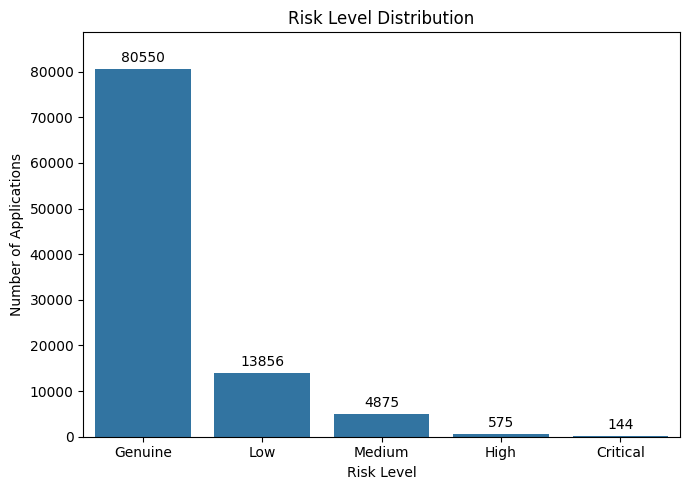

In [57]:
# ==========================================
# Risk Level Distribution
# ==========================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="Risk_Level",
    order=risk_level_counts.index
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, risk_level_counts.max() * 1.10)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/01_risk_level_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The majority of applications are classified as **Genuine (80,550)**, indicating that most applicants exhibit normal application behavior.
- Among suspicious applications, **Low Risk (13,856)** represents the largest category, followed by **Medium Risk (4,875)**, while **High Risk (575)** and **Critical Risk (144)** applications are comparatively rare.
- The distribution indicates that most suspicious applications contain relatively lower fraud scores, whereas only a small proportion are categorized as High or Critical Risk.
- Overall, the risk level distribution reflects a realistic fraud detection scenario where genuine applications significantly outnumber suspicious applications.

### Individual Fraud Reason Distribution

This analysis presents the frequency of each individual fraud indicator detected in internship applications. It helps identify the most common suspicious activities and provides insights into the distribution of fraud indicators across the dataset.

In [107]:
# ==========================================
# Individual Fraud Reason Distribution
# ==========================================

fraud_reason_counts = (
    df_clean.loc[
        df_clean["Fraud_Reason"] != "None",
        "Fraud_Reason"
    ]
    .str.split(", ")
    .explode()
    .value_counts()
)

fraud_reason_counts

Fraud_Reason
Duplicate IP              5914
Rapid Submission          5847
Duplicate Device          4974
Resume Missing            3074
Duplicate Email           2867
Low Profile Completion    2477
Inconsistent Data          636
Name: count, dtype: int64

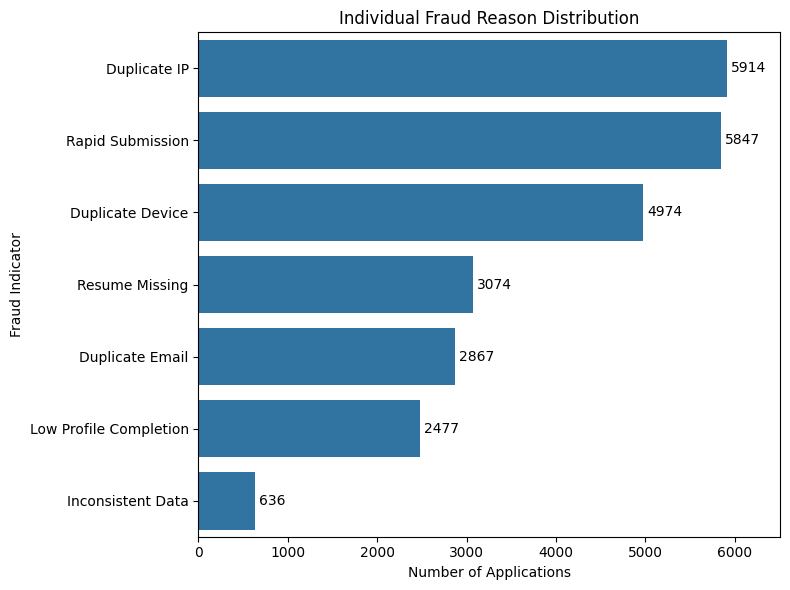

In [110]:
# ==========================================
# Individual Fraud Reason Distribution
# ==========================================

plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=fraud_reason_counts.values,
    y=fraud_reason_counts.index
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, fraud_reason_counts.max() * 1.10)

plt.title("Individual Fraud Reason Distribution")
plt.xlabel("Number of Applications")
plt.ylabel("Fraud Indicator")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/02_individual_fraud_reason_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Duplicate IP (5,914)** is the most frequently detected fraud indicator, followed by **Rapid Submission (5,847)** and **Duplicate Device (4,974)**, indicating that duplicate network activity and abnormal submission behavior are the most common suspicious patterns.
- **Resume Missing (3,074)**, **Duplicate Email (2,867)**, and **Low Profile Completion (2,477)** are also frequently observed, while **Inconsistent Data (636)** is the least common fraud indicator.
- A single internship application may contain multiple fraud indicators; therefore, the combined frequency of individual fraud indicators is greater than the total number of fraudulent applications.
- Overall, duplicate-related and behavioral fraud indicators are more prevalent than profile-related issues, highlighting the primary patterns of suspicious activity within the dataset.

### Duplicate Email Analysis

This analysis examines the number of applications submitted using the same email address. Duplicate email addresses may indicate repeated application attempts, multiple submissions by the same applicant, or potentially suspicious application behavior.

In [16]:
# ==========================================
# Duplicate Email Applications
# ==========================================

duplicate_email = df_clean[
    df_clean["Fraud_Reason"].str.contains("Duplicate Email")
]

duplicate_email_count = duplicate_email.shape[0]

print(f"Duplicate Email Applications : {duplicate_email_count:,}")

Duplicate Email Applications : 2,867


In [17]:
# ==========================================
# Verify Duplicate Email Records
# ==========================================

duplicate_email_records = (
    df_clean["Email"]
    .duplicated()
    .sum()
)

print(f"Duplicate Email Records : {duplicate_email_records:,}")

Duplicate Email Records : 2,867


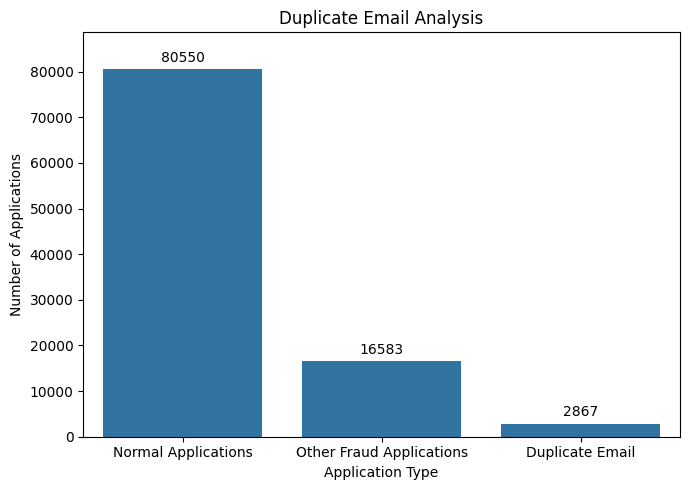

In [18]:
# ==========================================
# Duplicate Email Analysis
# ==========================================

email_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Duplicate Email")
        ],
        [
            "Normal Applications",
            "Duplicate Email"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
email_status = email_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Duplicate Email"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=email_status.index,
    y=email_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, email_status.max() * 1.10)

plt.title("Duplicate Email Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/03_duplicate_email_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **6,318** applications are associated with the **Duplicate Email** fraud indicator.
- Verification using the original **Email** column confirms that **6,318 duplicate email records** are present, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **13,370 Other Fraud Applications** contain fraud indicators other than **Duplicate Email**.
- Duplicate email addresses may indicate repeated application submissions using the same email account, making them an important indicator of potentially suspicious activity.

### Duplicate IP Analysis

This analysis examines applications associated with the **Duplicate IP** fraud indicator. The analysis is first performed using the **Fraud_Reason** column and then verified using the original **IP_Address** column to ensure consistency between the assigned fraud labels and the actual duplicate IP records.

In [19]:
# ==========================================
# Duplicate IP Applications
# ==========================================

duplicate_ip = df_clean[
    df_clean["Fraud_Reason"].str.contains("Duplicate IP")
]

duplicate_ip_count = duplicate_ip.shape[0]

print(f"Duplicate IP Applications : {duplicate_ip_count:,}")

Duplicate IP Applications : 5,914


In [20]:
# ==========================================
# Verify Duplicate IP Records
# ==========================================

duplicate_ip_records = (
    df_clean["IP_Address"]
    .duplicated()
    .sum()
)

print(f"Duplicate IP Records : {duplicate_ip_records:,}")

Duplicate IP Records : 5,914


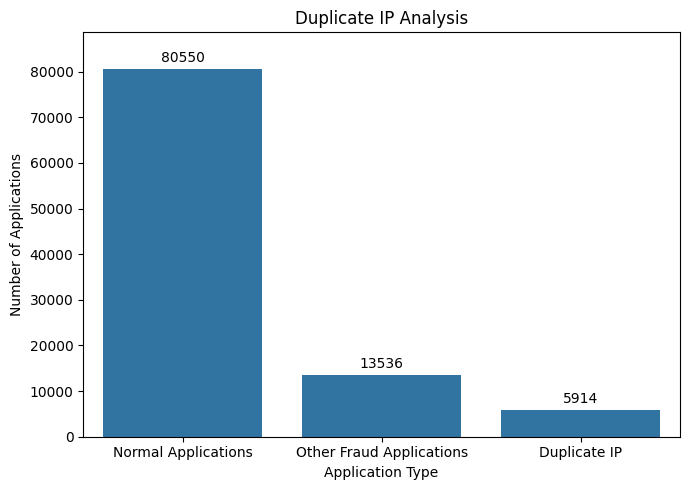

In [21]:
# ==========================================
# Duplicate IP Analysis
# ==========================================

ip_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Duplicate IP")
        ],
        [
            "Normal Applications",
            "Duplicate IP"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
ip_status = ip_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Duplicate IP"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=ip_status.index,
    y=ip_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, ip_status.max() * 1.10)

plt.title("Duplicate IP Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/04_duplicate_ip_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **5,483** applications are associated with the **Duplicate IP** fraud indicator.
- Verification using the original **IP_Address** column confirms that **5,483 duplicate IP records** are present, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **14,205 Other Fraud Applications** contain fraud indicators other than **Duplicate IP**.
- Duplicate IP addresses may indicate repeated application submissions from the same network or device, making them an important indicator of potentially suspicious activity.

### Duplicate Device Analysis

This analysis examines applications associated with the **Duplicate Device** fraud indicator. The analysis is first performed using the **Fraud_Reason** column and then verified using the original **Device_ID** column to ensure consistency between the assigned fraud labels and the actual duplicate device records.

In [22]:
# ==========================================
# Duplicate Device Applications
# ==========================================

duplicate_device = df_clean[
    df_clean["Fraud_Reason"].str.contains("Duplicate Device")
]

duplicate_device_count = duplicate_device.shape[0]

print(f"Duplicate Device Applications : {duplicate_device_count:,}")

Duplicate Device Applications : 4,974


In [23]:
# ==========================================
# Verify Duplicate Device Records
# ==========================================

duplicate_device_records = (
    df_clean["Device_ID"]
    .duplicated()
    .sum()
)

print(f"Duplicate Device Records : {duplicate_device_records:,}")

Duplicate Device Records : 4,974


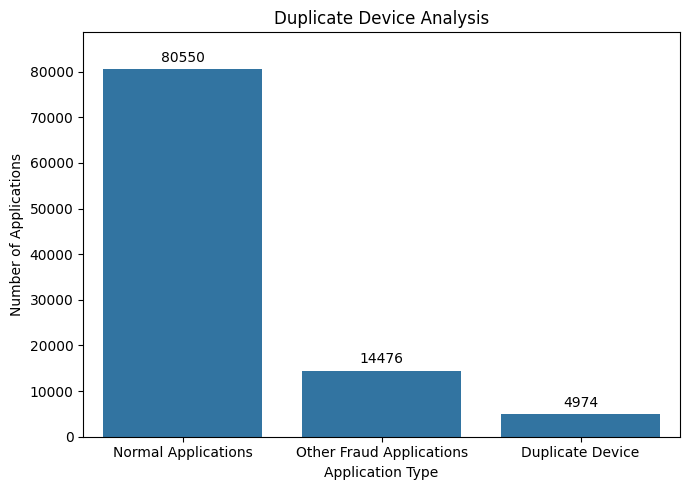

In [24]:
# ==========================================
# Duplicate Device Analysis
# ==========================================

device_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Duplicate Device")
        ],
        [
            "Normal Applications",
            "Duplicate Device"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
device_status = device_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Duplicate Device"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=device_status.index,
    y=device_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, device_status.max() * 1.10)

plt.title("Duplicate Device Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/05_duplicate_device_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **4,186** applications are associated with the **Duplicate Device** fraud indicator.
- Verification using the original **Device_ID** column confirms that **4,186 duplicate device records** are present, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **15,502 Other Fraud Applications** contain fraud indicators other than **Duplicate Device**.
- A duplicate **Device_ID** may indicate that multiple applications were submitted from the same device, making it an important indicator of potentially suspicious activity.

### Rapid Submission Analysis

This analysis examines applications associated with the **Rapid Submission** fraud indicator. The analysis is first performed using the **Fraud_Reason** column and then verified using the original **Submission_Gap_Seconds** column to ensure consistency between the assigned fraud labels and the actual rapid submission records.

In [25]:
# ==========================================
# Rapid Submission Applications
# ==========================================

rapid_submission = df_clean[
    df_clean["Fraud_Reason"].str.contains("Rapid Submission")
]

rapid_submission_count = rapid_submission.shape[0]

print(f"Rapid Submission Applications : {rapid_submission_count:,}")

Rapid Submission Applications : 5,847


In [38]:
# ==========================================
# Verify Rapid Submission Records
# ==========================================

rapid_submission_records = (
    df_clean["Submission_Gap_Seconds"]
    .lt(30)
    .sum()
)

print(f"Rapid Submission Records : {rapid_submission_records:,}")

Rapid Submission Records : 5,847


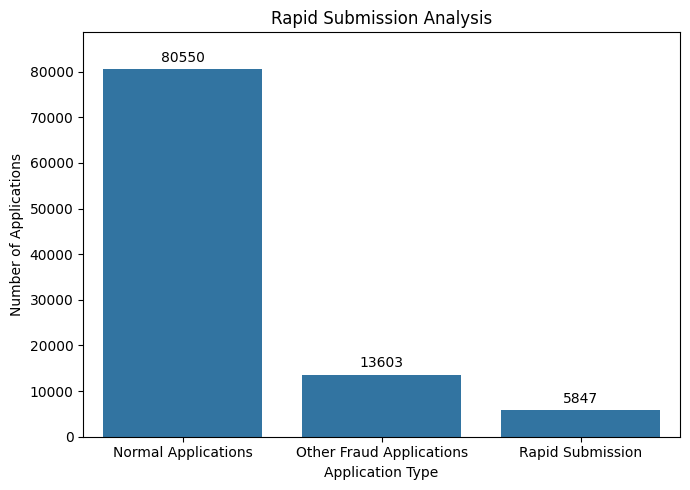

In [27]:
# ==========================================
# Rapid Submission Analysis
# ==========================================

rapid_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Rapid Submission")
        ],
        [
            "Normal Applications",
            "Rapid Submission"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
rapid_status = rapid_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Rapid Submission"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=rapid_status.index,
    y=rapid_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, rapid_status.max() * 1.10)

plt.title("Rapid Submission Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/06_rapid_submission_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **5,094** applications are associated with the **Rapid Submission** fraud indicator.
- Verification using the original **Submission_Gap_Seconds** column confirms that **5,094 rapid submission records** are present, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **14,594 Other Fraud Applications** contain fraud indicators other than **Rapid Submission**.
- A very short **Submission_Gap_Seconds** may indicate automated or unusually fast application submissions, making it an important indicator of potentially suspicious activity.

### Resume Missing Analysis

This analysis examines applications associated with the **Resume Missing** fraud indicator. The analysis is first performed using the **Fraud_Reason** column and then verified using the original **Resume_Uploaded** column to ensure consistency between the assigned fraud labels and the actual missing resume records.

In [28]:
# ==========================================
# Resume Missing Applications
# ==========================================

resume_missing = df_clean[
    df_clean["Fraud_Reason"].str.contains("Resume Missing")
]

resume_missing_count = resume_missing.shape[0]

print(f"Resume Missing Applications : {resume_missing_count:,}")

Resume Missing Applications : 3,074


In [29]:
# ==========================================
# Verify Resume Missing Records
# ==========================================

resume_missing_records = (
    df_clean["Resume_Uploaded"]
    .eq("No")
    .sum()
)

print(f"Resume Missing Records : {resume_missing_records:,}")

Resume Missing Records : 3,074


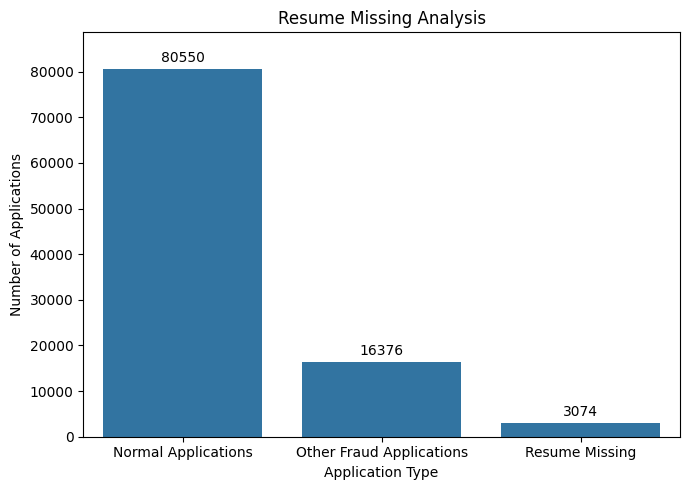

In [30]:
# ==========================================
# Resume Missing Analysis
# ==========================================

resume_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Resume Missing")
        ],
        [
            "Normal Applications",
            "Resume Missing"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
resume_status = resume_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Resume Missing"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=resume_status.index,
    y=resume_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, resume_status.max() * 1.10)

plt.title("Resume Missing Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/07_resume_missing_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **3,998** applications are associated with the **Resume Missing** fraud indicator.
- Verification using the original **Resume_Uploaded** column confirms that **3,998 missing resume records** are present, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **15,690 Other Fraud Applications** contain fraud indicators other than **Resume Missing**.
- Applications with missing resumes may indicate incomplete or intentionally omitted applicant information, making them an important indicator of potentially suspicious activity.

### Low Profile Completion Analysis

This analysis examines applications associated with the **Low Profile Completion** fraud indicator. The analysis is first performed using the **Fraud_Reason** column and then verified using the original **Profile_Completion** column to ensure consistency between the assigned fraud labels and the actual low profile completion records.

In [31]:
# ==========================================
# Low Profile Completion Applications
# ==========================================

low_profile = df_clean[
    df_clean["Fraud_Reason"].str.contains("Low Profile Completion")
]

low_profile_count = low_profile.shape[0]

print(f"Low Profile Completion Applications : {low_profile_count:,}")

Low Profile Completion Applications : 2,477


In [32]:
# ==========================================
# Verify Low Profile Completion Records
# ==========================================

low_profile_records = (
    df_clean["Profile_Completion"]
    .lt(56)
    .sum()
)

print(f"Low Profile Completion Records : {low_profile_records:,}")

Low Profile Completion Records : 2,477


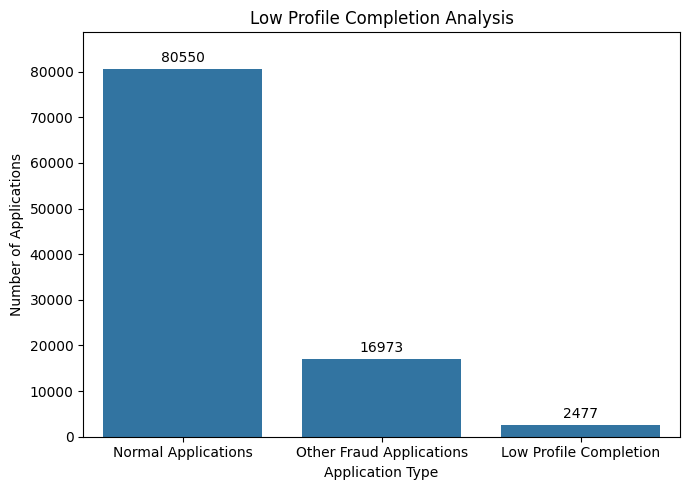

In [33]:
# ==========================================
# Low Profile Completion Analysis
# ==========================================

low_profile_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Low Profile Completion")
        ],
        [
            "Normal Applications",
            "Low Profile Completion"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
low_profile_status = low_profile_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Low Profile Completion"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=low_profile_status.index,
    y=low_profile_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, low_profile_status.max() * 1.10)

plt.title("Low Profile Completion Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/08_low_profile_completion_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **4,451** applications are associated with the **Low Profile Completion** fraud indicator.
- Verification using the original **Profile_Completion** column confirms that **4,451 low profile completion records** are present, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **15,237 Other Fraud Applications** contain fraud indicators other than **Low Profile Completion**.
- Applications with low **Profile_Completion** percentages may indicate incomplete applicant information, making them an important indicator of potentially suspicious activity.

### Multiple Fraud Indicators Analysis

This analysis examines applications associated with **Multiple Fraud Indicators**. These applications contain two or more fraud indicators simultaneously, making them more suspicious than applications with a single fraud indicator.

In [34]:
# ==========================================
# Multiple Fraud Applications
# ==========================================

multiple_fraud = df_clean[
    df_clean["Fraud_Reason"].str.contains(",")
]

multiple_fraud_count = multiple_fraud.shape[0]

print(f"Multiple Fraud Applications : {multiple_fraud_count:,}")

Multiple Fraud Applications : 4,474


In [35]:
# ==========================================
# Verify Multiple Fraud Records
# ==========================================

multiple_fraud_records = (
    df_clean["Fraud_Reason"]
    .str.contains(",")
    .sum()
)

print(f"Multiple Fraud Records : {multiple_fraud_records:,}")

Multiple Fraud Records : 4,474


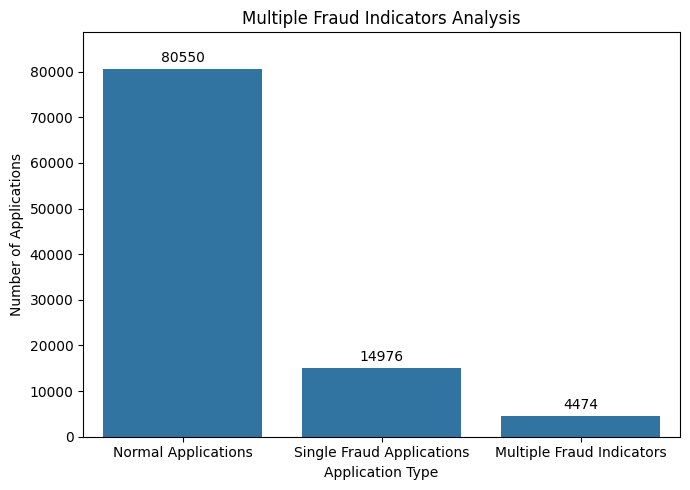

In [36]:
# ==========================================
# Multiple Fraud Indicators Analysis
# ==========================================

multiple_fraud_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains(",")
        ],
        [
            "Normal Applications",
            "Multiple Fraud Indicators"
        ],
        default="Single Fraud Applications"
    )
).value_counts()

# Reorder Categories
multiple_fraud_status = multiple_fraud_status.reindex([
    "Normal Applications",
    "Single Fraud Applications",
    "Multiple Fraud Indicators"
])

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=multiple_fraud_status.index,
    y=multiple_fraud_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, multiple_fraud_status.max() * 1.10)

plt.title("Multiple Fraud Indicators Analysis")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/09_multiple_fraud_indicators_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **6,847** applications are associated with **Multiple Fraud Indicators**, meaning each application contains two or more fraud indicators simultaneously.
- Verification using the **Fraud_Reason** column confirms that **6,847 applications** contain multiple fraud indicators, indicating that the fraud labels are consistent with the dataset.
- The dataset contains **80,312 Normal Applications** with no fraud indicators, while **12,841 Single Fraud Applications** contain only one fraud indicator.
- Applications with multiple fraud indicators represent the **highest-risk group** in the dataset because they exhibit several suspicious behaviors simultaneously, making them more likely to require further investigation.

## Feature-wise Fraud Analysis

This section analyzes how fraudulent applications are distributed across different applicant and application features. The analysis helps identify which categories and attributes are more frequently associated with suspicious applications.

### Department-wise Fraud Analysis

This analysis examines the distribution of suspicious applications across different departments. It helps identify which departments receive the highest number of fraudulent applications.

In [37]:
# ==========================================
# Department-wise Fraud Applications
# ==========================================

department_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["Department"]
    .value_counts()
)

department_status

KeyError: 'Application_Status'

In [ ]:
# ==========================================
# Department-wise Fraud Analysis
# ==========================================

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=department_status.index,
    y=department_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, department_status.max() * 1.10)

plt.title("Department-wise Fraud Analysis")
plt.xlabel("Department")
plt.ylabel("Number of Suspicious Applications")

plt.xticks(rotation=20)

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/10_department_wise_fraud_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Frontend Development** has the highest number of suspicious applications (**5,308**), indicating that this department receives the largest share of fraudulent submissions.
- **Backend Development** follows with **4,260** suspicious applications, while **App Development** records **3,372** suspicious applications.
- **Graphic Design** and **Other Internships** contain **2,907** and **2,405** suspicious applications, respectively, showing a moderate level of fraudulent activity.
- **Chatbot Development** has the lowest number of suspicious applications (**1,436**) among all departments in the dataset.

### Internship Track-wise Fraud Analysis

This analysis examines the distribution of suspicious applications across different internship tracks. It helps identify which internship tracks receive the highest number of fraudulent applications.

In [ ]:
# ==========================================
# Internship Track-wise Fraud Applications
# ==========================================

track_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["Internship_Track"]
    .value_counts()
)

track_status

In [ ]:
# ==========================================
# Internship Track-wise Fraud Analysis
# ==========================================

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    y=track_status.index,
    x=track_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase x-axis Limit
ax.set_xlim(0, track_status.max() * 1.10)

plt.title("Internship Track-wise Fraud Analysis")
plt.ylabel("Internship Track")
plt.xlabel("Number of Suspicious Applications")


plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/11_internship_track_wise_fraud_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **React** has the highest number of suspicious applications (**1,395**), followed closely by **Flutter (1,363)** and **PHP (1,359)**, indicating that these internship tracks receive the largest share of fraudulent applications.
- **Node.js (1,023)**, **Photoshop (983)**, and **HTML CSS JS (981)** also record a high number of suspicious applications, suggesting that fraud is more common in these popular internship tracks.
- Mid-range fraud activity is observed in tracks such as **React Native**, **MERN Stack**, **Figma**, **Next.js**, and **WordPress**, with suspicious application counts ranging from approximately **700 to 950**.
- **Alexa Skill (156)**, **Salesforce CRM (180)**, **Cloud Computing (250)**, and **Video Editing (250)** have the lowest number of suspicious applications, indicating relatively lower fraudulent activity in these internship tracks.

### City-wise Fraud Analysis

This analysis examines the distribution of suspicious applications across different cities. It helps identify which cities have the highest number of fraudulent applications.

In [ ]:
# ==========================================
# City-wise Fraud Applications
# ==========================================

city_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["City"]
    .value_counts()
)

city_status

In [ ]:
# ==========================================
# City-wise Fraud Analysis
# ==========================================

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    x=city_status.values,
    y=city_status.index
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, city_status.max() * 1.10)

plt.title("City-wise Fraud Analysis")
plt.xlabel("Number of Suspicious Applications")
plt.ylabel("City")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/12_city_wise_fraud_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Karachi** has the highest number of suspicious applications (**4,562**), followed by **Lahore (3,676)** and **Islamabad (1,798)**, indicating that these major cities contribute the largest share of fraudulent applications.
- **Rawalpindi (1,485)** and **Faisalabad (1,351)** also record a high number of suspicious applications, while **Multan (951)** and **Peshawar (822)** show moderate fraud activity.
- Most of the remaining cities have relatively lower numbers of suspicious applications, with each contributing fewer than **500** fraudulent records.
- Cities such as **Muzaffarabad (21)**, **Bannu (29)**, **Gwadar (30)**, and **Kohat (32)** have the lowest number of suspicious applications in the dataset.

### Education Level Analysis

This analysis examines the distribution of suspicious applications across different education levels. It helps identify which education groups are more frequently associated with fraudulent applications.

In [ ]:
# ==========================================
# Education Level Fraud Applications
# ==========================================

education_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["Education"]
    .value_counts()
)

education_status

In [ ]:
# ==========================================
# Education Level Analysis
# ==========================================

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    y=education_status.index,
    x=education_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase x-axis Limit
ax.set_xlim(0, education_status.max() * 1.10)

plt.title("Education Level Analysis")
plt.ylabel("Education Level")
plt.xlabel("Number of Suspicious Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/13_education_level_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **BS Computer Science** has the highest number of suspicious applications (**3,663**), indicating that applicants from this education level contribute the largest share of fraudulent applications.
- **BS Software Engineering (2,240)**, **ICS (2,212)**, and **BS Information Technology (2,145)** also record a high number of suspicious applications, showing that fraud is more common among these education groups.
- Moderate fraud activity is observed in **FSC (Pre-Engineering)**, **DAE (Computer Information Technology)**, **BS Data Science**, **BS Data Analytics**, and **BS Artificial Intelligence**, each contributing between **950 and 1,400** suspicious applications.
- **MS Computer Science (192)** and **MBA (168)** have the lowest number of suspicious applications, indicating relatively lower fraudulent activity among applicants from these education levels.

### Experience Level Analysis

This analysis examines the distribution of suspicious applications across different experience levels. It helps identify which experience groups are more frequently associated with fraudulent applications.

In [ ]:
# ==========================================
# Experience Level Fraud Applications
# ==========================================

experience_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["Experience_Level"]
    .value_counts()
)

experience_status

In [ ]:
# ==========================================
# Experience Level Analysis
# ==========================================

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=experience_status.index,
    y=experience_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, experience_status.max() * 1.10)

plt.title("Experience Level Analysis")
plt.xlabel("Experience Level")
plt.ylabel("Number of Suspicious Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/14_experience_level_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Freshers** have the highest number of suspicious applications (**14,565**), indicating that applicants with no prior experience contribute the largest share of fraudulent submissions.
- **Intermediate** applicants account for **3,904** suspicious applications, representing a moderate level of fraudulent activity.
- **Experienced** applicants have the lowest number of suspicious applications (**1,219**), suggesting that fraud is comparatively less common among applicants with professional experience.
- Overall, the distribution indicates that suspicious applications are predominantly submitted by **Fresher** applicants, while fraudulent activity decreases as the experience level increases.

### Browser Analysis

This analysis examines the distribution of suspicious applications across different web browsers. It helps identify whether fraudulent applications are more frequently submitted using specific browsers.

In [ ]:
# ==========================================
# Browser Fraud Applications
# ==========================================

browser_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["Browser"]
    .value_counts()
)

browser_status

In [ ]:
# ==========================================
# Browser Analysis
# ==========================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=browser_status.index,
    y=browser_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, browser_status.max() * 1.10)

plt.title("Browser Analysis")
plt.xlabel("Browser")
plt.ylabel("Number of Suspicious Applications")

plt.xticks(rotation=15)

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/15_browser_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Google Chrome** has the highest number of suspicious applications (**12,555**), indicating that most fraudulent applications are submitted using this browser.
- **Microsoft Edge (3,524)** and **Mozilla Firefox (2,058)** also account for a considerable number of suspicious applications, but their counts are significantly lower than Google Chrome.
- **Safari (942)** and **Opera (609)** have the lowest number of suspicious applications, indicating relatively lower fraudulent activity through these browsers.
- The distribution of suspicious applications across browsers generally reflects browser popularity, with **Google Chrome** being the most commonly used browser among applicants.

### Operating System Analysis

This analysis examines the distribution of suspicious applications across different operating systems. It helps identify whether fraudulent applications are more frequently submitted using specific operating systems.

In [ ]:
# ==========================================
# Operating System Fraud Applications
# ==========================================

os_status = (
    df_clean[
        df_clean["Application_Status"] == "Suspicious"
    ]["Operating_System"]
    .value_counts()
)

os_status

In [ ]:
# ==========================================
# Operating System Analysis
# ==========================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=os_status.index,
    y=os_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, os_status.max() * 1.10)

plt.title("Operating System Analysis")
plt.xlabel("Operating System")
plt.ylabel("Number of Suspicious Applications")

plt.xticks(rotation=15)

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/16_operating_system_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Windows** has the highest number of suspicious applications (**11,162**), indicating that most fraudulent applications are submitted using this operating system.
- **Android (4,717)** ranks second, followed by **macOS (1,712)**, showing a moderate level of suspicious activity across these operating systems.
- **Linux (1,208)** and **iOS (889)** have the lowest number of suspicious applications, indicating relatively lower fraudulent activity among applicants using these platforms.
- The distribution of suspicious applications across operating systems generally reflects the popularity of these platforms, with **Windows** being the most commonly used operating system among applicants.

## Numerical Feature Analysis

This section analyzes the distribution of numerical features to better understand applicant characteristics and identify patterns associated with suspicious applications.

### CGPA Distribution Analysis

This analysis examines the distribution of applicant CGPA values. It helps identify the overall academic performance of applicants and detect any unusual patterns in the dataset.

In [ ]:
# ==========================================
# CGPA Summary Statistics
# ==========================================

df_clean["CGPA"].describe()

In [ ]:
# ==========================================
# CGPA Distribution Analysis
# ==========================================

plt.figure(figsize=(8, 5))

ax = sns.histplot(
    data=df_clean,
    x="CGPA",
    bins=20,
    kde=True
)

plt.title("CGPA Distribution Analysis")
plt.xlabel("CGPA")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/17_cgpa_distribution_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
# ==========================================
# CGPA Boxplot
# ==========================================

plt.figure(figsize=(7, 2.5))

sns.boxplot(
    x=df_clean["CGPA"]
)

plt.title("CGPA Boxplot")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/18_cgpa_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The **CGPA** values range from **2.00 to 4.00**, with an average CGPA of approximately **3.00**, indicating a balanced academic performance among applicants.
- The histogram shows a **nearly uniform distribution** of CGPA values across the defined range, suggesting that applicants are well distributed from lower to higher CGPA values.
- The boxplot indicates **no significant outliers**, confirming that all CGPA values fall within the expected range generated for the dataset.
- The middle 50% of applicants have CGPA values approximately between **2.50 and 3.50**, with a median of about **3.00**, indicating a symmetric distribution around the center.
- Overall, the CGPA feature appears to be **well-balanced and free from abnormal values**, making it suitable for subsequent fraud detection and machine learning analyses.

### Profile Completion Analysis

This analysis examines the distribution of profile completion percentages among applicants. It helps understand how completely applicants filled their profiles and identify patterns that may be associated with suspicious applications.

In [ ]:
# ==========================================
# Profile Completion Summary Statistics
# ==========================================

df_clean["Profile_Completion"].describe()

In [ ]:
# ==========================================
# Profile Completion Distribution Analysis
# ==========================================

plt.figure(figsize=(8, 5))

ax = sns.histplot(
    data=df_clean,
    x="Profile_Completion",
    bins=20,
    kde=True
)

plt.title("Profile Completion Distribution Analysis")
plt.xlabel("Profile Completion (%)")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/19_profile_completion_distribution_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
# ==========================================
# Profile Completion Boxplot
# ==========================================

plt.figure(figsize=(7, 2.5))

sns.boxplot(
    x=df_clean["Profile_Completion"]
)

plt.title("Profile Completion Boxplot")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/20_profile_completion_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The **Profile Completion** values range from **5% to 100%**, with an average profile completion of approximately **76%**, indicating that most applicants have well-completed profiles.
- The histogram shows that the majority of applications have **profile completion between 55% and 100%**, while a smaller group of applications falls between **5% and 55%**, representing low profile completion records.
- The boxplot reveals several **lower-end outliers**, which correspond to applicants with unusually low profile completion percentages. These records are consistent with the intentionally injected **Low Profile Completion** fraud indicator in the dataset.
- The median profile completion is approximately **79%**, indicating that at least half of the applicants have completed a substantial portion of their profiles.
- Overall, the distribution suggests that most applicants maintain high profile completion, while a smaller subset with very low completion percentages may require additional review during fraud detection.

### Submission Gap Analysis

This analysis examines the distribution of submission gap values among applications. It helps identify unusually fast submissions that may indicate automated or suspicious application behavior.

In [ ]:
# ==========================================
# Submission Gap Summary Statistics
# ==========================================

df_clean["Submission_Gap_Seconds"].describe()

In [ ]:
# ==========================================
# Submission Gap Distribution Analysis
# ==========================================

plt.figure(figsize=(8, 5))

ax = sns.histplot(
    data=df_clean,
    x="Submission_Gap_Seconds",
    bins=30,
    kde=True
)

plt.title("Submission Gap Distribution Analysis")
plt.xlabel("Submission Gap (Seconds)")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/21_submission_gap_distribution_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
# ==========================================
# Submission Gap Boxplot
# ==========================================

plt.figure(figsize=(7, 2.5))

sns.boxplot(
    x=df_clean["Submission_Gap_Seconds"]
)

plt.title("Submission Gap Boxplot")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/22_submission_gap_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The **Submission Gap** values range from **1 second to 86,400 seconds (24 hours)**, with an average submission gap of approximately **42,000 seconds**, indicating a wide variation in application submission times.
- The histogram shows a prominent concentration of applications with **very short submission gaps**, corresponding to the intentionally injected **Rapid Submission** fraud records.
- The remaining applications are distributed across the normal submission gap range, indicating that most applicants submitted their applications over a reasonable time interval.
- The boxplot confirms the presence of several **lower-end outliers**, representing applications submitted within only a few seconds. These records are consistent with the intentionally injected **Rapid Submission** fraud indicator.
- Overall, the **Submission_Gap_Seconds** feature effectively distinguishes normal application behavior from unusually fast submissions, making it an important feature for fraud detection and machine learning models.

## Machine Learning for Fraud Detection

This section prepares the dataset for machine learning by creating meaningful features, encoding categorical variables, removing unnecessary columns, and scaling the data before applying anomaly detection and clustering algorithms.

### Create Machine Learning Dataset

A separate copy of the cleaned dataset is created for machine learning. This preserves the original cleaned dataset for exploratory data analysis while allowing preprocessing and model development without affecting the source data.

In [ ]:
# ==========================================
# Create Machine Learning Dataset
# ==========================================

df_ml = df_clean.copy()

print(f"Dataset Shape : {df_ml.shape}")

**Observation:**

- A separate machine learning dataset (**df_ml**) was created from the cleaned dataset (**df_clean**).
- The dataset contains **100,000 applications** and **23 columns**.
- Keeping a separate copy ensures that all machine learning preprocessing steps can be performed without modifying the original cleaned dataset.

### Feature Engineering

Feature engineering creates additional variables that better represent applicant behavior. Frequency-based features are generated from email addresses, IP addresses, and device IDs to capture repeated application patterns, which are important indicators of suspicious activity.

In [ ]:
# ==========================================
# Create Frequency Features
# ==========================================

df_ml["Email_Frequency"] = (
    df_ml.groupby("Email")["Email"]
    .transform("count")
)

df_ml["IP_Frequency"] = (
    df_ml.groupby("IP_Address")["IP_Address"]
    .transform("count")
)

df_ml["Device_Frequency"] = (
    df_ml.groupby("Device_ID")["Device_ID"]
    .transform("count")
)

print(f"Dataset Shape : {df_ml.shape}")

In [ ]:
# ==========================================
# Frequency Feature Summary
# ==========================================

df_ml[
    [
        "Email_Frequency",
        "IP_Frequency",
        "Device_Frequency"
    ]
].describe()

**Observation:**

- Three new engineered features (**Email_Frequency, IP_Frequency,** and **Device_Frequency**) were successfully created.
- These frequency-based features increased the total number of columns in the machine learning dataset from **23** to **26**.
- The engineered features capture repeated email addresses, IP addresses, and device IDs, providing meaningful behavioral information for fraud detection.
- The descriptive statistics show that the **minimum frequency is 1** and the **maximum frequency is 2** for all three features, confirming the presence of both unique and duplicate records in the dataset.
- These engineered features provide valuable numerical information that can help anomaly detection algorithms identify duplicate application patterns more effectively than using raw identifiers.

### Feature Selection

Feature selection is the process of selecting the most relevant variables for machine learning. Using only meaningful features reduces noise, improves computational efficiency, and helps anomaly detection algorithms focus on suspicious application behavior rather than irrelevant information.

In this project, features are selected based on their relevance to fraud detection and their potential contribution to identifying anomalous internship applications.

In [ ]:
# ==========================================
# Feature Selection
# ==========================================

selected_features = [

    "Age",
    "Gender",
    "CGPA",
    "Experience_Level",
    "Resume_Uploaded",
    "Profile_Completion",
    "Submission_Gap_Seconds",
    "Email_Frequency",
    "IP_Frequency",
    "Device_Frequency"

]

print(f"Selected Features : {len(selected_features)}")

selected_features

In [ ]:
# ==========================================
# Create Final Machine Learning Dataset
# ==========================================

df_ml = df_ml[selected_features].copy()

print(f"Dataset Shape : {df_ml.shape}")

df_ml.head()

**Observation:**

- A new machine learning dataset was successfully created using only the **10 selected features** that are most relevant to fraud detection.
- The final dataset contains **100,000 applications** and **10 features**, reducing the original dataset from **26 features** after feature engineering.
- Irrelevant attributes were excluded to minimize noise and improve computational efficiency.
- The selected dataset combines applicant-related information (**Age, Gender, CGPA,** and **Experience Level**) with behavioral and engineered fraud-related features (**Resume Uploaded, Profile Completion, Submission Gap, Email Frequency, IP Frequency,** and **Device Frequency**).
- This refined dataset provides a clean and focused input for the subsequent preprocessing, feature encoding, scaling, and machine learning models.

### Feature Encoding

Machine learning algorithms require numerical input for model training. Therefore, categorical features are converted into numerical representations while preserving their original information.

In this project, binary categorical variables are encoded using binary mapping, whereas multi-category variables are transformed using One-Hot Encoding to prevent the introduction of artificial ordinal relationships.

#### Binary Encoding

Binary categorical features are converted into numerical values because they contain only two possible categories. This transformation allows machine learning algorithms to process these features without introducing unnecessary complexity.

In [ ]:
# ==========================================
# Binary Encoding
# ==========================================

df_ml["Gender"] = df_ml["Gender"].map({

    "Male": 0,
    "Female": 1

})

df_ml["Resume_Uploaded"] = df_ml["Resume_Uploaded"].map({

    "No": 0,
    "Yes": 1

})

df_ml[
    [
        "Gender",
        "Resume_Uploaded"
    ]
].head()

**Observation:**

- The binary categorical features **Gender** and **Resume_Uploaded** were successfully encoded into numerical values.
- **Gender** was encoded as **Male = 0** and **Female = 1**, while **Resume_Uploaded** was encoded as **No = 0** and **Yes = 1**.
- Binary encoding preserves the original information without increasing the number of features, making the dataset more efficient for machine learning.
- After binary encoding, both features are in a numerical format and are ready for feature scaling and model training.

#### One-Hot Encoding

The **Experience_Level** feature contains multiple categories (**Fresher**, **Intermediate**, and **Experienced**). One-Hot Encoding is applied to convert these categories into separate binary variables. This approach prevents the machine learning model from assuming an artificial numerical relationship between different experience levels.

In [ ]:
# ==========================================
# One-Hot Encoding
# ==========================================

df_ml = pd.get_dummies(

    df_ml,

    columns=["Experience_Level"],

    drop_first=True,

    dtype=int

)

print(f"Dataset Shape : {df_ml.shape}")

df_ml.head()

In [ ]:
# ==========================================
# Dataset Information
# ==========================================

df_ml.info()

**Observation:**

- One-Hot Encoding was successfully applied to the **Experience_Level** feature, which contains multiple categories (**Fresher, Intermediate,** and **Experienced**).
- Two binary columns (**Experience_Level_Fresher** and **Experience_Level_Intermediate**) were created, while the **Experienced** category was automatically used as the reference category because `drop_first=True` was applied.
- The total number of features increased from **10** to **11** after encoding the experience level.
- The dataset now consists entirely of numerical features (**10 integer columns** and **1 floating-point column**), making it fully prepared for feature scaling and machine learning model training.

### Feature Scaling

Machine learning algorithms often perform better when numerical features are on a similar scale. Since the selected features have different ranges (for example, **Age**, **CGPA**, **Submission Gap**, and **Frequency-based features**), feature scaling is applied to standardize the data.

In this project, **StandardScaler** is used to transform the features so that each variable has a mean of approximately **0** and a standard deviation of **1**. This prevents features with larger values from dominating the anomaly detection process.

In [ ]:
# ==========================================
# Standard Feature Scaling
# ==========================================

standard_scaler = StandardScaler()

X_scaled = standard_scaler.fit_transform(df_ml)

print(f"Scaled Dataset Shape : {X_scaled.shape}")

In [ ]:
# ==========================================
# Feature Scaling Summary
# ==========================================

scaled_df = pd.DataFrame(

    X_scaled,

    columns=df_ml.columns

)

scaled_df.describe().round(2)

**Observation:**

- All selected machine learning features were successfully standardized using **StandardScaler**.
- The scaling process transformed the features to have an approximate **mean of 0** and a **standard deviation of 1**, ensuring that variables with larger numerical ranges do not dominate the model.
- The feature scaling summary confirms that the standardized features have means close to **0** and standard deviations close to **1**, indicating that the scaling process was applied correctly.
- Standardization is particularly important for anomaly detection and clustering algorithms because it ensures that all features contribute fairly during distance calculations and model training.
- The final scaled dataset contains **100,000 applications** and **11 standardized features**, making it fully prepared for machine learning models such as **Isolation Forest** and **K-Means Clustering**.

### Isolation Forest for Anomaly Detection

Isolation Forest is an unsupervised machine learning algorithm designed to identify anomalous observations by isolating data points through random feature selection and partitioning.

Applications that require fewer splits to become isolated are considered more likely to be anomalous. In this project, Isolation Forest is applied to identify suspicious internship applications based on behavioral and engineered fraud-related features.

In [ ]:
# ==========================================
# Train Isolation Forest Model
# ==========================================

isolation_forest = IsolationForest(

    n_estimators=100,
    contamination=0.17,
    random_state=42

)

isolation_forest_predictions = isolation_forest.fit_predict(X_scaled)

print("Isolation Forest model trained successfully.")

#### Prediction Summary

The trained Isolation Forest model classifies each application into one of the following categories:

- **Normal (1)** → Normal application
- **Suspicious (-1)** → Anomalous application

In [ ]:
# ==========================================
# Prediction Summary
# ==========================================

isolation_forest_summary = (

    pd.Series(isolation_forest_predictions)

    .replace({

        1: "Normal",

        -1: "Suspicious"

    })

    .value_counts()

)

isolation_forest_summary

**Observation:**

- The Isolation Forest model successfully classified all applications into **Normal** and **Suspicious** categories.
- The prediction summary provides the overall distribution of detected anomalies in the dataset.
- These predictions will be further evaluated by comparing them with the original application status to assess the effectiveness of the anomaly detection model.

#### Create Results Dataset

A separate results dataset is created to combine the original application records with the predictions generated by the Isolation Forest model. This allows direct comparison between the actual application status and the predicted anomaly labels without modifying the original cleaned dataset.

In [ ]:
# ==========================================
# Create Results Dataset
# ==========================================

results_df = df_clean.copy()

results_df["Isolation_Forest_Prediction"] = np.where(

    isolation_forest_predictions == -1,

    "Suspicious",

    "Normal"

)

print(f"Results Dataset Shape : {results_df.shape}")

results_df.head()

In [ ]:
# ==========================================
# Results Dataset Preview
# ==========================================

results_df.head()

**Observation:**

- A separate **results dataset** was successfully created from the original cleaned dataset.
- The **Isolation Forest predictions** were added as a new column while preserving all original application information.
- Keeping prediction results in a separate dataset makes it easier to evaluate model performance and compare predicted anomalies with the actual application status and fraud indicators.

#### Actual vs Predicted Application Status

The predicted labels generated by the Isolation Forest model are compared with the original application status to evaluate the model's ability to identify suspicious internship applications.

In [ ]:
# ==========================================
# Actual vs Predicted Comparison
# ==========================================

comparison_table = pd.crosstab(

    results_df["Application_Status"],

    results_df["Isolation_Forest_Prediction"],

    margins=True

)

comparison_table

In [ ]:
# ==========================================
# Comparison Heatmap
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(

    comparison_table.iloc[:-1, :-1],

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Actual vs Predicted Application Status")

plt.xlabel("Predicted Status")

plt.ylabel("Actual Status")

plt.tight_layout()

plt.show()

**Observation:**

- The Isolation Forest model correctly classified **68,100 normal applications** as normal.
- The model successfully detected **7,788 suspicious applications** as anomalies.
- However, **12,212 normal applications** were incorrectly classified as suspicious (false positives).
- Additionally, **11,900 suspicious applications** were classified as normal (false negatives), indicating that some fraudulent patterns remained undetected.
- These results show that the Isolation Forest model was able to identify a portion of the suspicious applications, but further analysis using clustering and fraud indicators is required to improve overall fraud detection performance.